<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
     Customer Segmentation on Walmart Sales Data

</center></p></h1>

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Table Content  
</center></p></h1>

-<ul>
  <li><a href="#1">1. Introduction</a></li>

  <li><a href="#2">2. Data Understanding and Preprocessing</a>
    <ul>
      <li><a href="#2.1">2.1. Importing Libraries</a></li>
      <li><a href="#2.2">2.2. Loading Dataset</a></li>
      <li><a href="#2.3">2.3. Basic Understanding Data</a></li>
      <li><a href="#2.4">2.4. Exploratory Data Analysis (EDA)</a></li>
      <li><a href="#2.5">2.5. Pairplot- correlations between all features</a></li>
      <li><a href="#2.6">2.6. Correlation</a></li>
      <li><a href="#2.7">2.7. Remove Outliers</a></li>
      <li><a href="#2.8">2.8. Handling Missing Values</a></li>
      <li><a href="#2.9">2.9. Feature Engineering (RFM Calculation)</a></li>
      <li><a href="#2.10">2.10. X/Splite Data</a></li>
      <li><a href="#2.11">2.11. Data Normalization</a></li>
      <li><a href="#2.12">2.12. PCA Perform</a></li>
    </ul>
  </li>

  <li><a href="#3">3. Customer Segmentation Using K-Means</a>
    <ul>
      <li><a href="#3.1">3.1. Hopkins Test </a></li>
      <li><a href="#3.2">3.2. Elbow Method (WCSS Plot)</a></li>
      <li><a href="#3.3">3.3. Silhouette Analysis</a></li>
      <li><a href="#3.4">3.4. Applying K-Means Clustering</a></li>
    </ul>
  </li>

  <li><a href="#4">4. Visualization and Insights</a>
  <li><a href="#5">5. DBSCAN clusters</a>
  <li><a href="#6">6. DCompare Kmeans & DBSCAN clusters</a>
  <li><a href="#7">7. Conclusion and Analysis of Customer Segmentation</a></li>
</ul>



<a id="1"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     1. Introduction
</center></p></h1>

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 10px;
            background:#F2FFFF">

 <p style="color: green; font-weight: bold; font-size: 16px;">Customer Segmentation using Walmart Transactional Data</p>

  <p>
      In today’s competitive retail environment, understanding customer behavior is essential for increasing sales,
        improving customer experience, and building long-term loyalty. This project applies
        <b>customer segmentation</b> on Walmart transactional sales data to identify meaningful customer groups based on
     their <b>purchase patterns</b> and <b>demographic characteristics</b>.
    </p>

  <p>
        By clustering customers into distinct segments, Walmart can develop <b>data-driven marketing strategies</b>,
        optimize product offerings, and improve customer retention through targeted engagement.
    </p>

  <hr style="border: 1px solid #008000;">

 <p style="color: green; font-weight: bold; font-size: 16px;">🎯 Objective</p>
    <p>
        The primary goal is to segment customers into distinct groups based on their purchasing behavior and demographic
        attributes. This segmentation will help Walmart:
    </p>
    <ul>
        <li>Identify high-value customer segments</li>
        <li>Personalize marketing campaigns and promotions</li>
        <li>Improve customer retention and satisfaction</li>
        <li>Optimize product strategy and inventory decisions</li>
    </ul>

 <hr style="border: 1px solid #008000;">

  <p style="color: green; font-weight: bold; font-size: 16px;">📌 Dataset Overview</p>
    <p>
        The dataset contains <b>550,068 entries</b> including customer demographics, product information, and purchase
        amounts.
    </p>
    <ul>
        <li><b>User_ID</b>: Unique customer identifier</li>
        <li><b>Product_ID</b>: Unique product identifier</li>
        <li><b>Gender</b>: Customer gender</li>
        <li><b>Age</b>: Customer age group</li>
        <li><b>Occupation</b>: Occupation code</li>
        <li><b>City_Category</b>: City category (A, B, C)</li>
        <li><b>Marital_Status</b>: Marital status indicator</li>
        <li><b>Product_Category_1/2/3</b>: Product category codes</li>
        <li><b>Purchase</b>: Purchase amount (spending behavior)</li>
    </ul>

 <hr style="border: 1px solid #008000;">

 <p style="color: green; font-weight: bold; font-size: 16px;">🧠 Approach</p>
    <ol>
        <li><b>Data Preprocessing</b>: Cleaning, handling missing values, encoding categorical variables, and scaling features.</li>
        <li><b>Clustering with K-Means</b>: Identify distinct customer groups using unsupervised learning.</li>
        <li><b>PCA (Dimensionality Reduction)</b>: Reduce dimensionality and visualize customer clusters effectively.</li>
        <li><b>Insights & Visualization</b>: Profile each segment and provide actionable business recommendations.</li>
    </ol>

</div>


<a id="2.1"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     2.1. Libraries
</center></p></h1>

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler, RobustScaler,MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import  calinski_harabasz_score, davies_bouldin_score

from sklearn.decomposition import PCA
from random import sample
from numpy.random import uniform
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')

<a id="2.2"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      2.2.Data Loading  
</center></p></h1>

In [ ]:
df = pd.read_csv('walmart.csv')


In [3]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


<a id="2.3"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     2.3. Basic Understanding Data  
</center></p></h1>

###  Checking Dimensions of the Data.

In [5]:
df.shape

(550068, 10)

In [4]:
# the number of rows and columns in train dataset 
rows , columns = df.shape 
print ("The number of rows in train dataset : " , rows)
print ("The number of columns in train dataset : " , columns)

The number of rows in train dataset :  550068
The number of columns in train dataset :  10


<p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold">
<div style="border-radius: 5px;
           -webkit-border-radius: 5px;
           -moz-border-radius: 5px;
           font-family: cursive;
           border: 3px solidrgb(0, 90, 128);
           text-align: justify;
           color: black;
           font-size: 14px;
           padding: 5px;
           background:#F2FFFF"><span>Obervation :</span><br>
    <ul>
        <li>This dataset includes the details of <b>550068/b> samples</li>
        <li>The number of features for the dataframe is equal to <b>10</b></li>
    </ul></div>

###  Checking the basic information of dataset.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


###  Checking NaN values in our Dataset.

In [7]:
df.isnull().sum().to_frame().rename(columns={0:"Total No. of Missing Values"})

,Total No. of Missing Values
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


In [8]:
print("Duplicate Values =",df.duplicated().sum())

Duplicate Values = 0


<p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold">
<div style="border-radius: 5px;
           -webkit-border-radius: 5px;
           -moz-border-radius: 5px;
           font-family: cursive;
           border: 3px solidrgb(0, 90, 128);
           text-align: justify;
           color: black;
           font-size: 14px;
           padding: 5px;
           background:#F2FFFF"><span>Obervation :</span><br>
    <ul>
        <li>From the above output we can say that there is <b>0</b> </li>
    </ul></div>

###  Showing Only Categorical & Numerical Features.

In [9]:
df.dtypes 

User_ID                        int64
Product_ID                    object
Gender                        object
Age                           object
Occupation                     int64
City_Category                 object
Stay_In_Current_City_Years    object
Marital_Status                 int64
Product_Category               int64
Purchase                       int64
dtype: object

In [10]:
df.select_dtypes(exclude="object").head()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
0,1000001,10,0,3,8370
1,1000001,10,0,1,15200
2,1000001,10,0,12,1422
3,1000001,10,0,12,1057
4,1000002,16,0,8,7969


In [11]:
df.dtypes[df.dtypes == 'object']

Product_ID                    object
Gender                        object
Age                           object
City_Category                 object
Stay_In_Current_City_Years    object
dtype: object

<h1 id ="import_lib" ></a> Descriptive Statistics Analysis</h1>

In [12]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000



<div style="border-radius: 12px;
     -webkit-border-radius: 12px;
     -moz-border-radius: 12px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 15px;
     padding: 18px;
     line-height: 1.7;">

  <p style="font-weight: bold; color:rgb(20, 1, 1); font-size: 18px; margin-top:0;">
    📌 Key Insights from Walmart Customer Segmentation (EDA Findings)
  </p>

  <ul style="margin: 0; padding-left: 22px;">
    <li><b>Highly Active Customers:</b> Certain users (e.g., <b>1001680</b>) and products (e.g., <b>P00265242</b>) show significant repeat activity. This can guide <b>loyalty programs</b>, <b>personalized marketing</b>, and targeted retention strategies.</li>

<li><b>Male Dominance:</b> The majority of transactions come from <b>male customers</b>. Marketing strategies can prioritize this demographic while exploring growth opportunities in female customer segments.</li>

 <li><b>Young Adult Market:</b> The <b>26–35</b> age group dominates purchases, indicating a strong young adult customer base. This group may be more <b>tech-savvy</b> and responsive to <b>online promotions</b> and digital marketing campaigns.</li>

 <li><b>City Category B:</b> Customers from <b>Category B</b> cities are highly active, suggesting potential for <b>regional targeting</b>, local campaigns, and city-based product optimization.</li>

  <li><b>Popular Product Categories:</b> Certain product categories (e.g., <b>Category 5</b>) and frequently purchased items should be prioritized for <b>inventory planning</b>, <b>stock optimization</b>, and promotional discounts.</li>
  </ul>
</div>

<a id="2.4"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     2.4. Exploratory Data Analysis (EDA)
</center></p></h1>

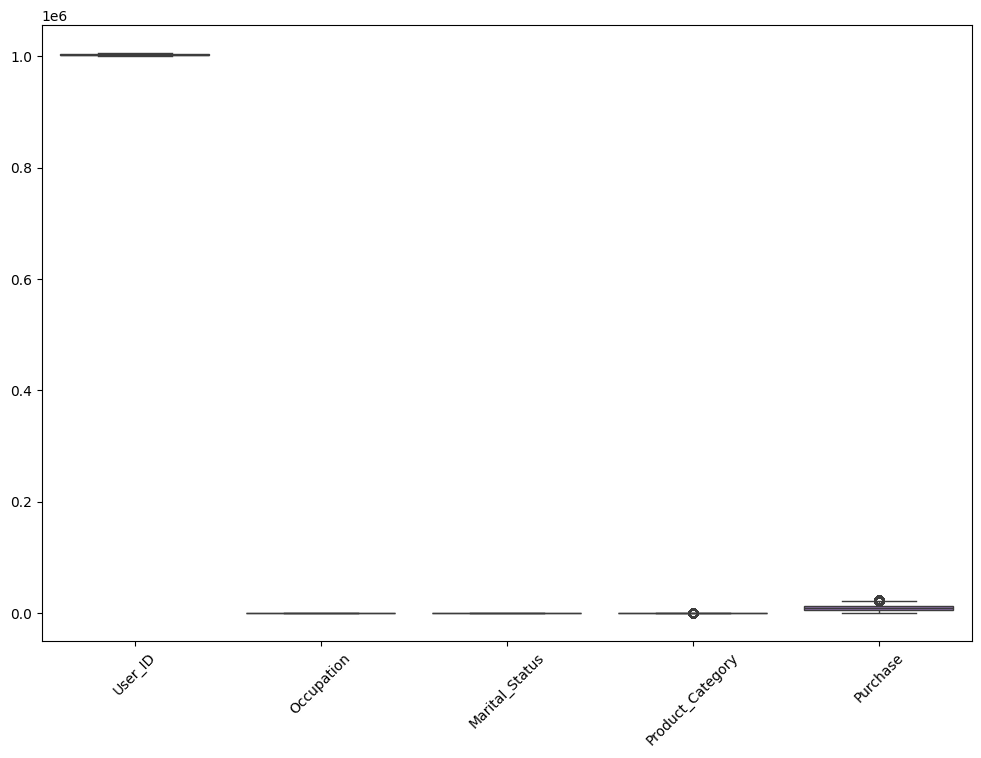

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.xticks(rotation=45)
plt.show()

In [15]:
tot = df.groupby('Gender').sum(numeric_only = True).reset_index()
tot

,Gender,User_ID,Occupation,Marital_Status,Product_Category,Purchase
0,F,136234060927,915426,56988,776517,1186232642
1,M,415500008355,3527312,168349,2196199,3909580100


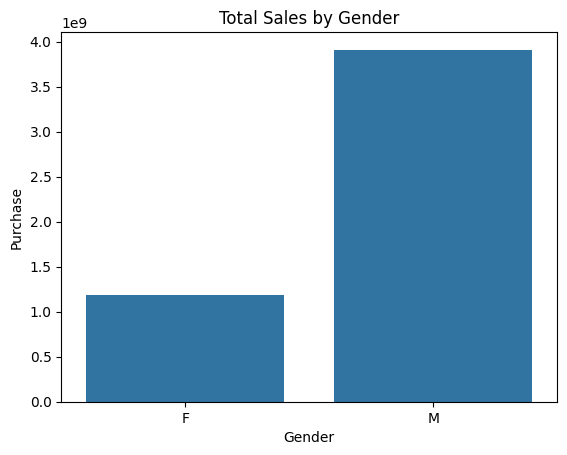

In [16]:
sns.barplot(data = tot, x = 'Gender', y = 'Purchase')
plt.title('Total Sales by Gender')
plt.show()

In [18]:
tot_pur_by_ms = df.groupby('Marital_Status').sum(numeric_only = True).reset_index()
tot_pur_by_ms

,Marital_Status,User_ID,Occupation,Product_Category,Purchase
0,0,325705005668,2579917,1733758,3008927447
1,1,226029063614,1862821,1238958,2086885295


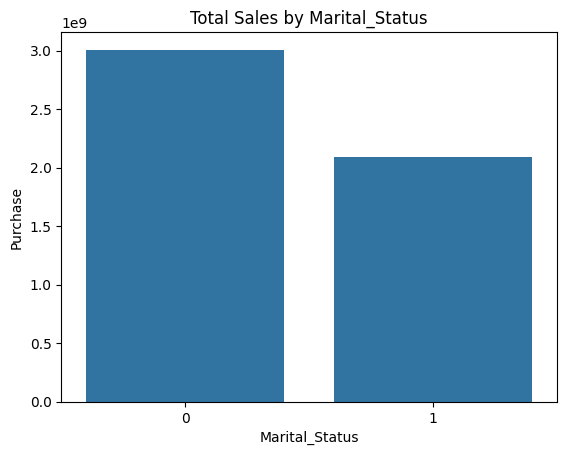

In [19]:
sns.barplot(data = tot_pur_by_ms, y = 'Purchase', x = 'Marital_Status')
plt.title('Total Sales by Marital_Status')
plt.show()

     Age       User_ID  Occupation  Marital_Status  Product_Category  \
0   0-17   15143112813      132309               0             76775   
1  18-25   99939196632      671348           21116            509371   
2  26-35  220270500414     1734073           86291           1166945   
3  36-45  110350311441      972225           43636            604438   
4  46-50   45846804203      389239           33011            262424   

     Purchase  
0   134913183  
1   913848675  
2  2031770578  
3  1026569884  
4   420843403  


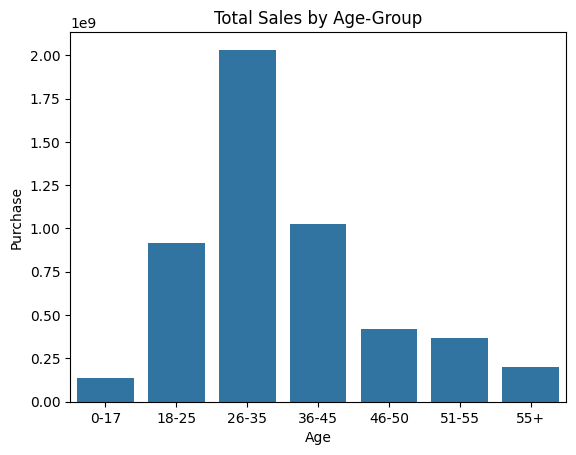

In [20]:
tot_pur_by_age = df.groupby('Age').sum(numeric_only = True).reset_index()
print(tot_pur_by_age.head())


sns.barplot(data = tot_pur_by_age, x = 'Age', y = 'Purchase')
plt.title('Total Sales by Age-Group')
plt.show()

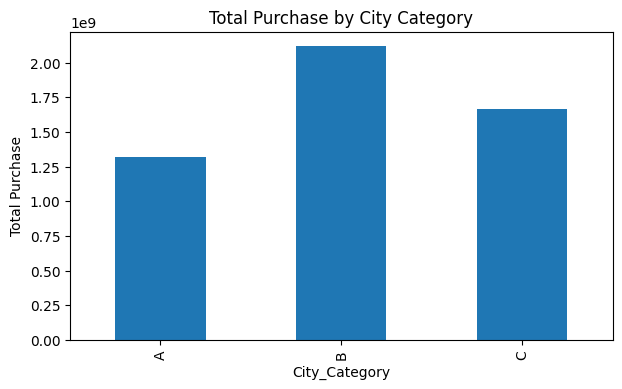

In [22]:
df.groupby("City_Category")["Purchase"].sum().plot(kind="bar", figsize=(7,4), title="Total Purchase by City Category")
plt.ylabel("Total Purchase")
plt.show()


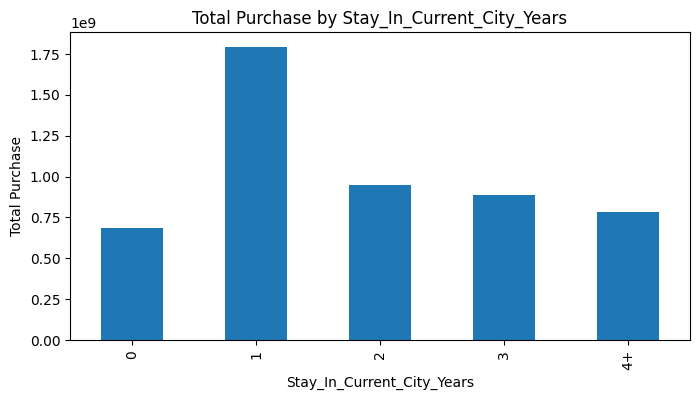

In [23]:
df.groupby("Stay_In_Current_City_Years")["Purchase"].sum().plot(kind="bar", figsize=(8,4))
plt.title("Total Purchase by Stay_In_Current_City_Years")
plt.xlabel("Stay_In_Current_City_Years")
plt.ylabel("Total Purchase")
plt.show()

In [29]:
print("\n--- Age Group Count ---")
print(df["Age"].value_counts())


--- Age Group Count ---
Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64


In [25]:
df[df["Gender"] == "M"].median(numeric_only=True)

User_ID             1003041.0
Occupation                7.0
Marital_Status            0.0
Product_Category          5.0
Purchase               8098.0
dtype: float64

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     
<p style="font-weight: bold; color:rgb(1, 17, 8);">Individuals with an income of 137 are predominantly male.</p>
     
<p style="font-weight: bold; color:rgb(0, 5, 2);">
         Furthermore, their incomes are generally above the overall average. Among male customers specifically, these incomes are significantly higher.
     </p>
</div>

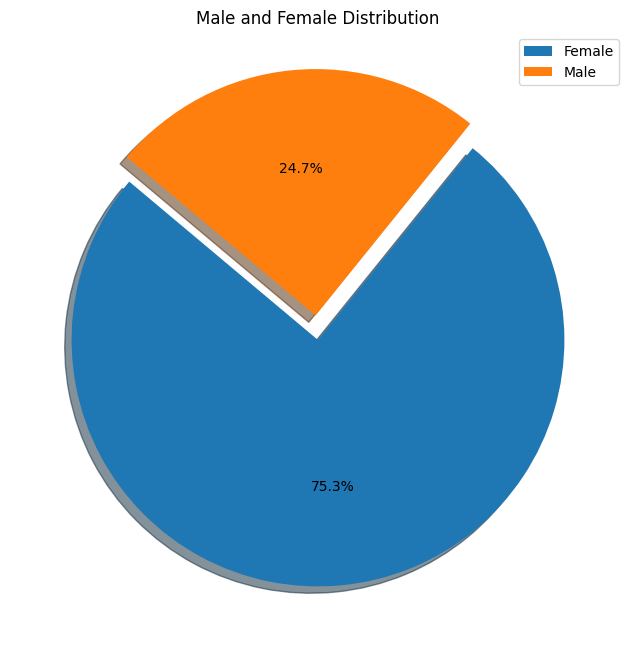

In [26]:
plt.figure(figsize=(8, 8))

explode = [0, 0.1]
plt.pie(df['Gender'].value_counts(),
        explode=explode,
        autopct='%1.1f%%',
        shadow=True,
        startangle=140)
plt.legend(labels=['Female', 'Male'])
plt.title('Male and Female Distribution')
plt.axis('off')
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     
<p style="font-weight: bold; color:rgb(1, 17, 8);">It has been observed that there are slightly more females than males in the dataset.</p>
</div>


In [27]:
for col in df.select_dtypes(include=["number"]).columns:
    skewness = df[col].skew()
    kurtosis = df[col].kurt()
    print(f"{col} - Skewness: {skewness:.2f}, Kurtosis: {kurtosis:.2f}")

User_ID - Skewness: 0.00, Kurtosis: -1.20
Occupation - Skewness: 0.40, Kurtosis: -1.22
Marital_Status - Skewness: 0.37, Kurtosis: -1.86
Product_Category - Skewness: 1.03, Kurtosis: 1.23
Purchase - Skewness: 0.60, Kurtosis: -0.34


from IPython.display import display, HTML

display(HTML("""
<div style="border-radius: 12px;
     -webkit-border-radius: 12px;
     -moz-border-radius: 12px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 15px;
     padding: 18px;
     line-height: 1.7;">

  <p style="font-weight: bold; color:rgb(20, 1, 1); font-size: 18px; margin-top:0;">
    📌 Conclusive Insights & Recommendations from Walmart EDA
  </p>

  <ul style="margin: 0; padding-left: 22px;">
    <li><b>Customer Demographics & Behavior:</b> Male customers contribute 75% of purchases (~3.9B). The 26–35 age group dominates (~2B). Recommendation: Engage female customers via targeted campaigns. Focus marketing on 18–45 age groups using social media and lifestyle promotions.</li>

 <li><b>Geographic Insights:</b> City B leads in purchases (~2.1B), followed by City C and City A. Recommendation: Run regional campaigns, loyalty programs for City B, and promotional efforts to grow City A market share.</li>

 <li><b>Spending Patterns by Stay Duration:</b> 1-year residents spend the most (~1.79B); new residents (0 years) spend the least (~683M). Recommendation: Provide welcome offers for new residents and loyalty rewards for long-term customers.</li>

   <li><b>Product Preferences:</b> Categories 1, 5, 8 dominate purchases. Categories 19, 20, 13 are less popular. Recommendation: Prioritize stock and promotions for popular categories; analyze low-performing categories for potential repositioning or bundling.</li>

 <li><b>Occupation Insights:</b> Occupations 4, 0, 7 are top spenders. Recommendation: Develop occupation-specific campaigns and consider corporate partnerships or discounts.</li>
  </ul>

</div>
"""))


<a id="2.5"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">  2.5.Pairplot- correlations between all features.</p>
</div>

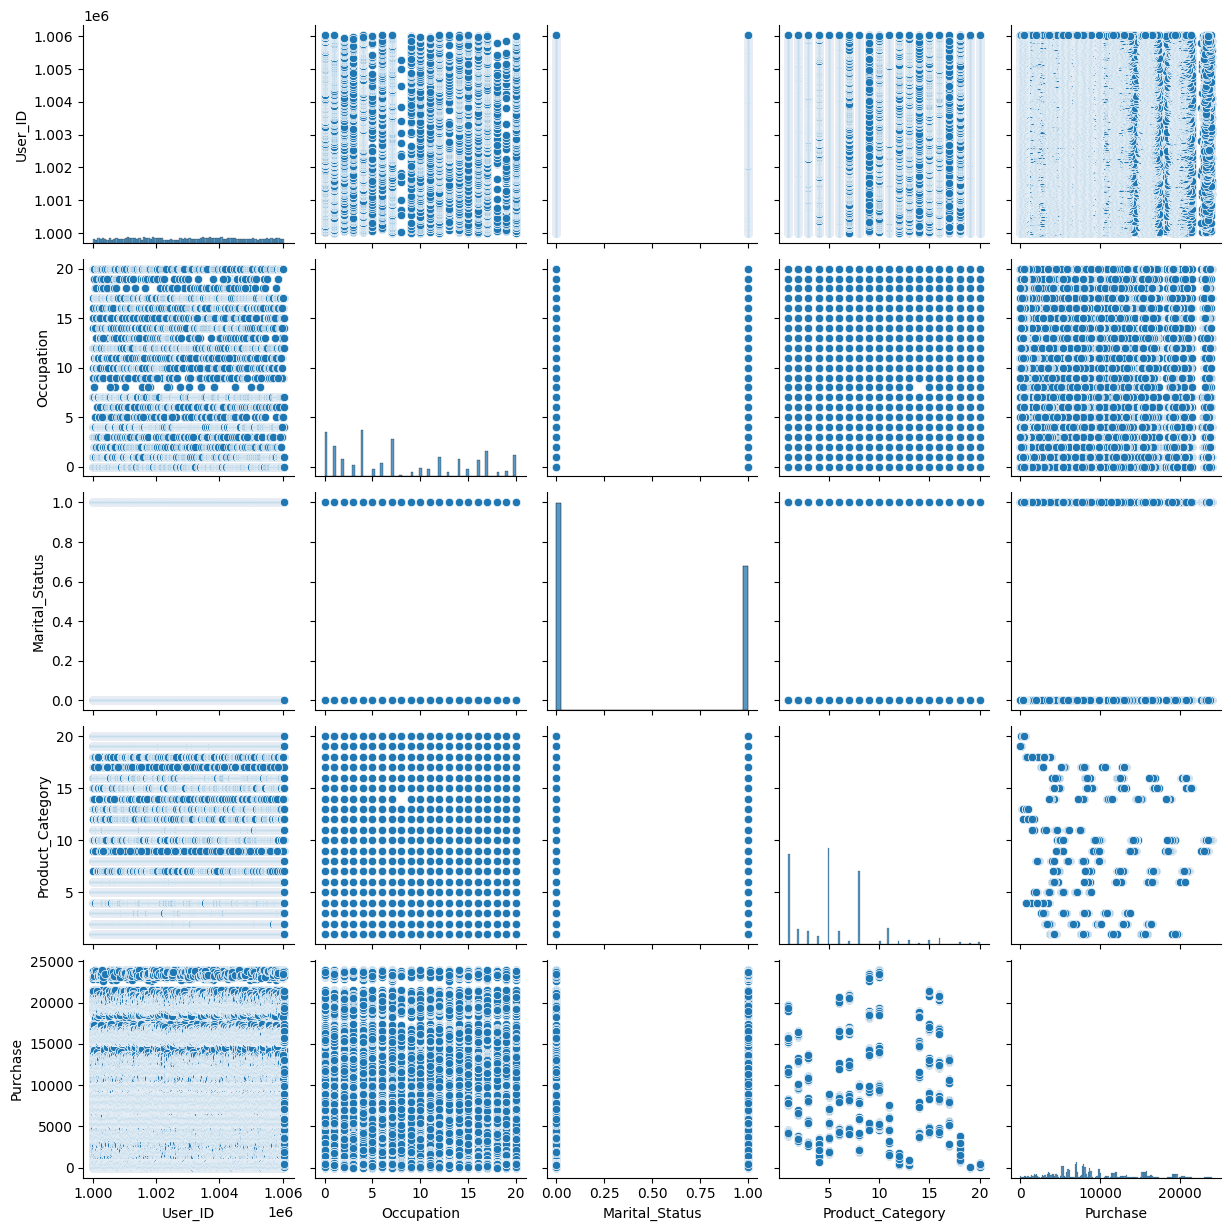

In [28]:
sns.pairplot(df, palette="bright" )
plt.show()

<a id="2.6"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 2.6. Correlation between independent variable and dependent variable </p>

<Axes: >

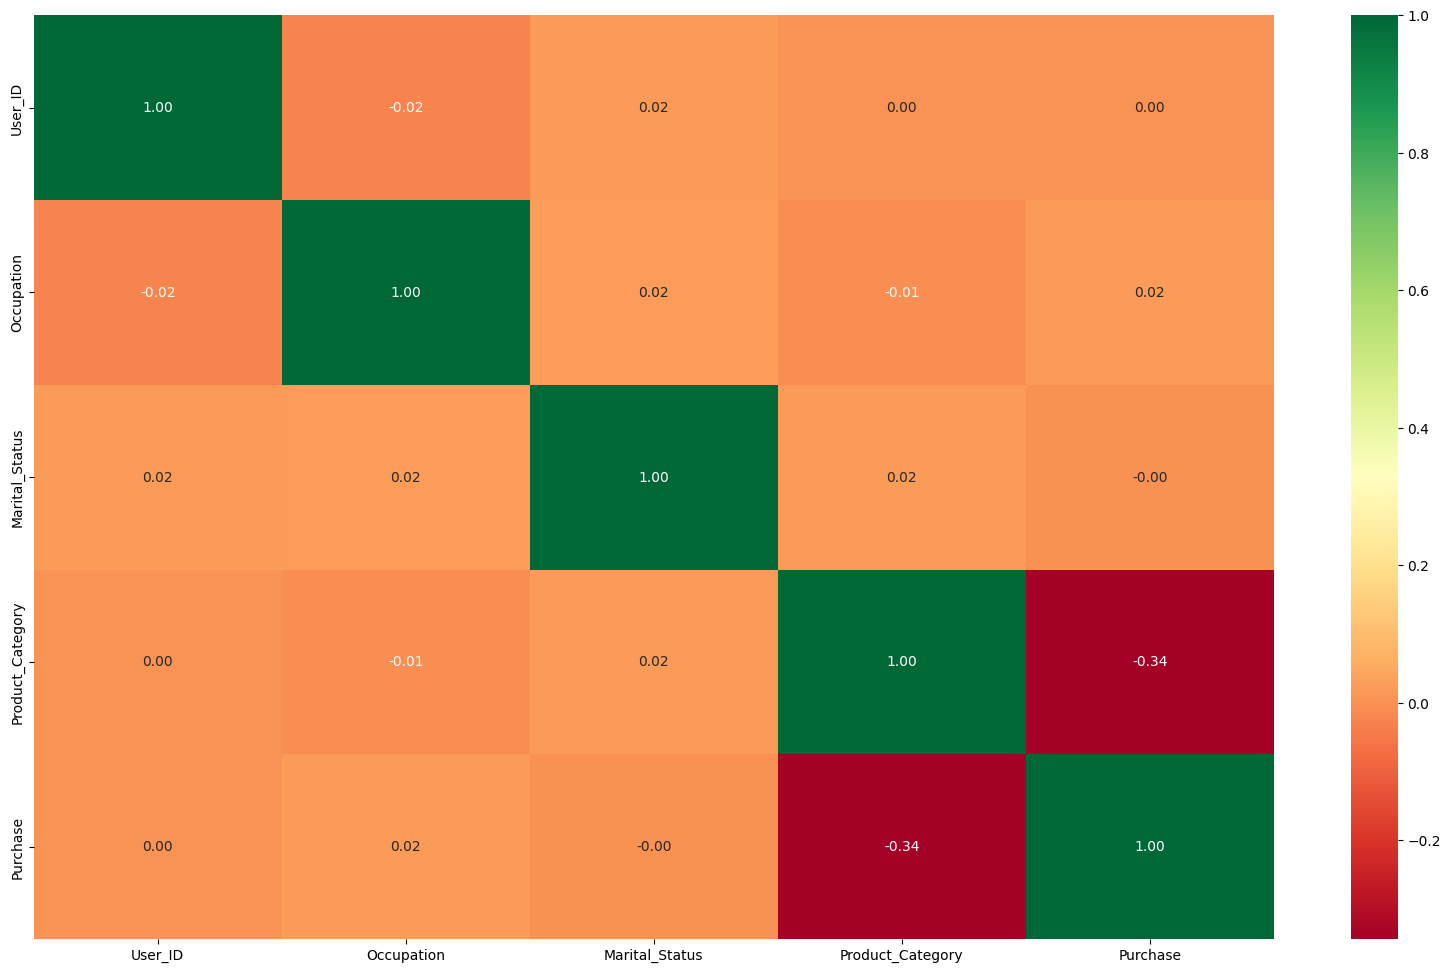

In [30]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20,12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn')

<a id="2.7"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">2.7 Remove Outliers</p>
</div>

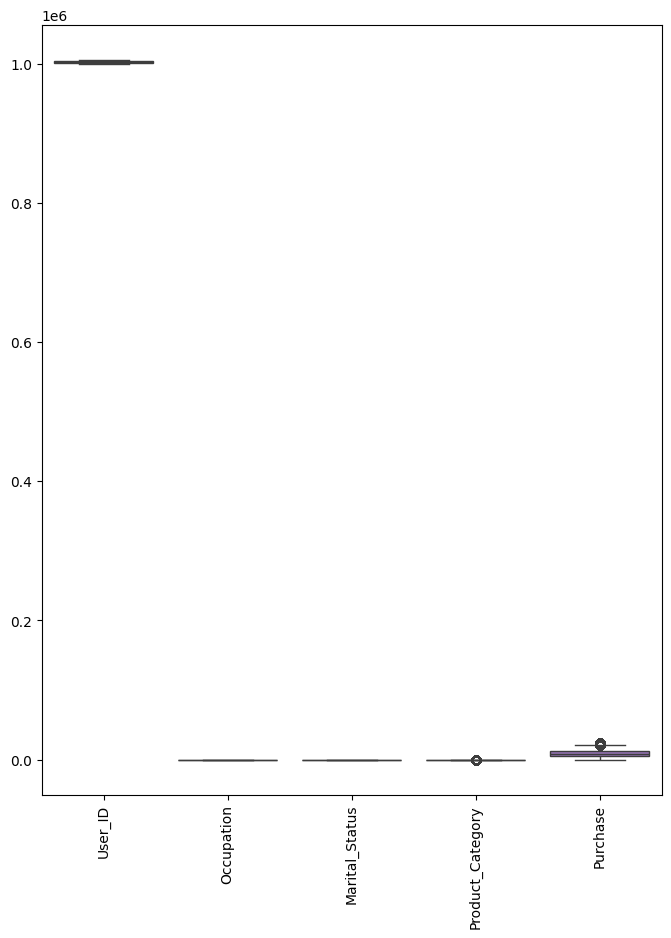

In [31]:
plt.figure(figsize=(8, 10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [32]:
Q1 = df["Purchase"].quantile(0.25)
Q3 = df["Purchase"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Outlier Bounds:", lower, upper)

df_no_out = df[(df["Purchase"] >= lower) & (df["Purchase"] <= upper)]
print("Shape after outlier removal:", df_no_out.shape)

Outlier Bounds: -3523.5 21400.5
Shape after outlier removal: (547391, 10)


<a id="2.8"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 2.8. Missing Data</p>
</div>

## Missing data

In [33]:
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64

In [34]:
# Detection missing values
print(f"The number of missing values in dataset : \n{df.isnull().sum()} " )

The number of missing values in dataset : 
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64 


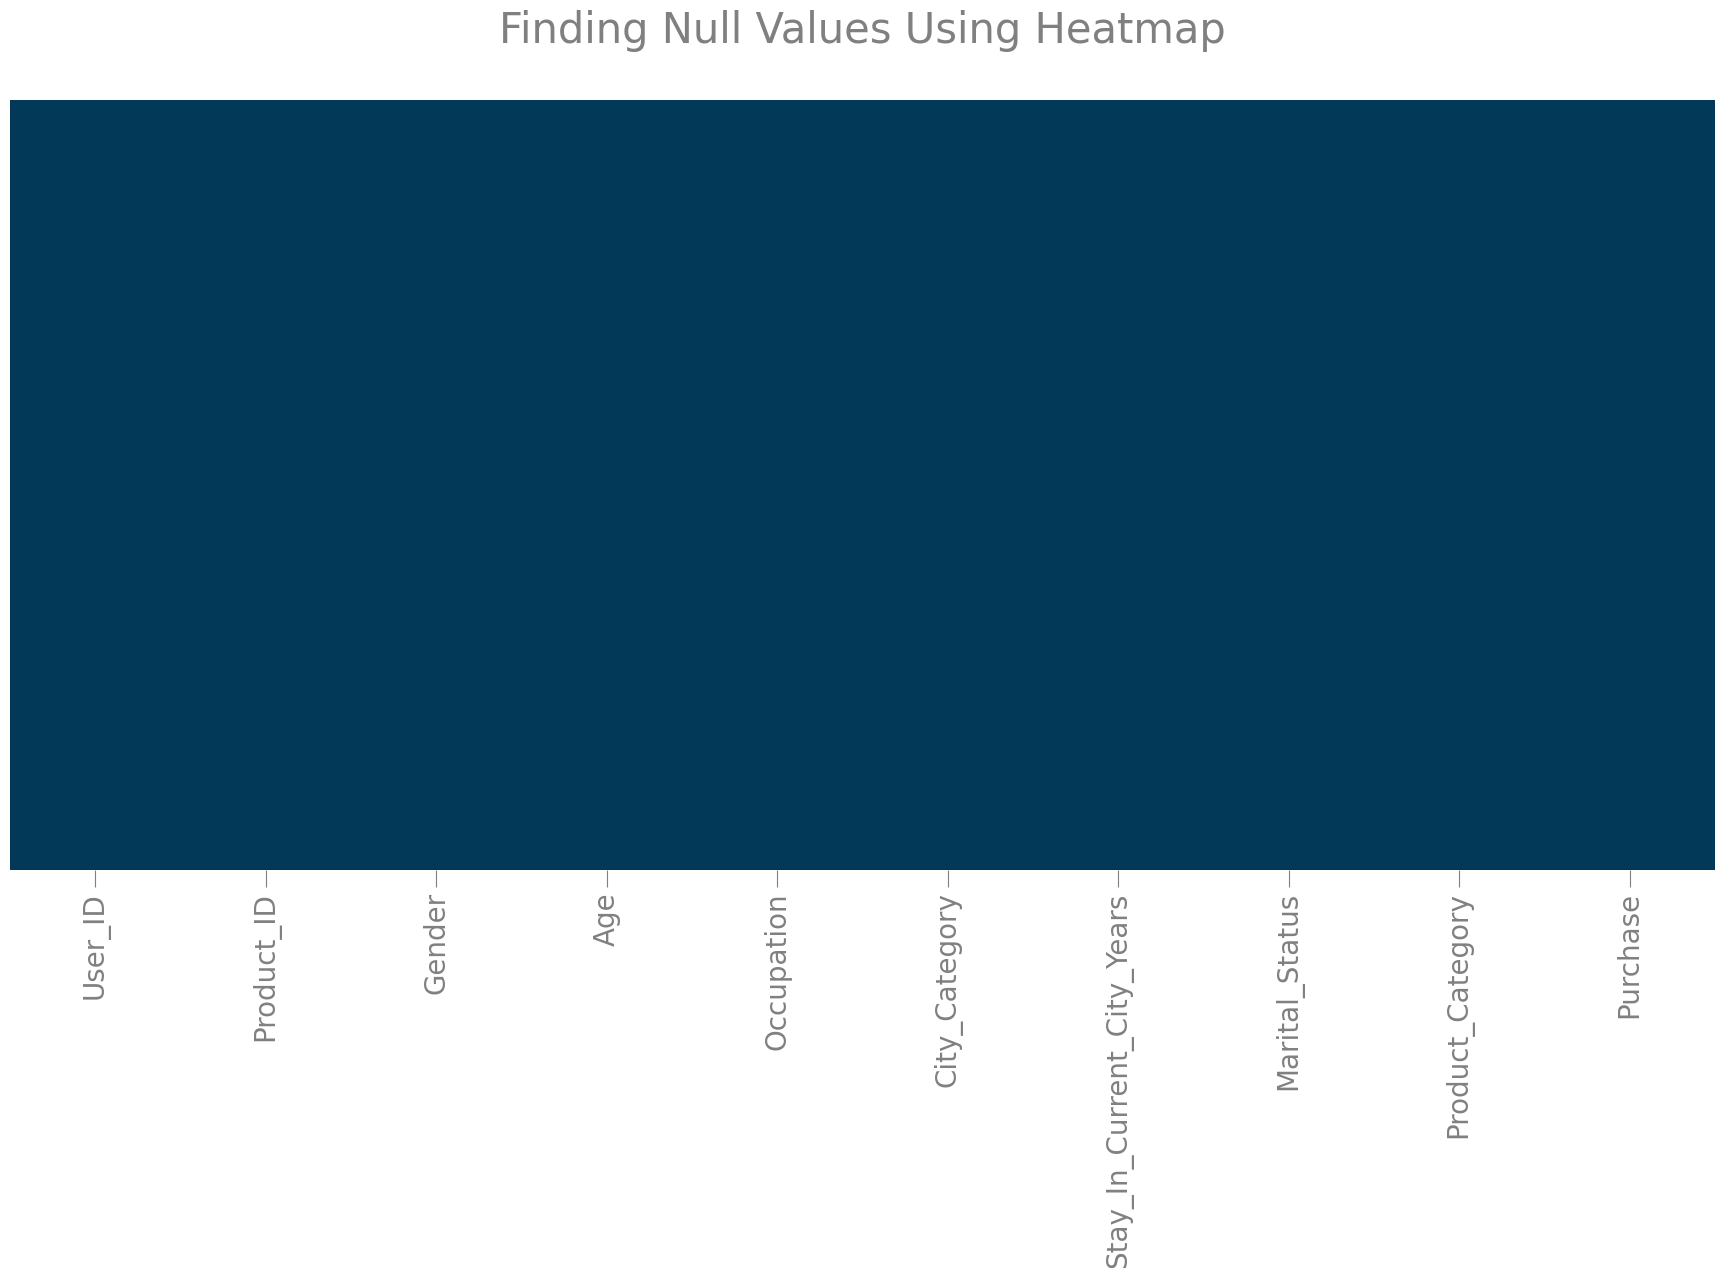

In [35]:
plt.figure(figsize=(22,10))
plt.xticks(size=20,color='grey')
plt.tick_params(size=12,color='grey')
plt.title('Finding Null Values Using Heatmap\n',color='grey',size=30)
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=False,
            cmap='PuBu_r',
            )
plt.show()

<a id="2.9"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      2.9. Featuring 
</div>
</center></p></h1>

In [ ]:
age_map = {
    "0-17": 8,
    "18-25": 21.5,
    "26-35": 30.5,
    "36-45": 40.5,
    "46-50": 48,
    "51-55": 53,
    "55+": 60}

df_no_out["Age_num"] = df_no_out["Age"].map(age_map)

# Customer-level aggregation
rfm_age = df_no_out.groupby("User_ID").agg(
    Frequency=("Product_ID", "count"),
    Monetary=("Purchase", "sum"),
    Avg_Age=("Age_num", "mean")
).reset_index()

print("\nRFM+Age shape:", rfm_age.shape)
display(rfm_age.head())


RFM+Age shape: (5891, 4)


,User_ID,Frequency,Monetary,Avg_Age
0,1000001,35,334093,8.0
1,1000002,77,810472,60.0
2,1000003,29,341635,30.5
3,1000004,14,206468,48.0
4,1000005,106,821001,30.5


<a id="2.10"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     2.10. Data split
</div>
</center></p></h1>

In [37]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase'],
      dtype='object')

In [79]:
X = rfm_age[["Frequency", "Monetary", "Avg_Age"]]
print("\nX shape:", X.shape)


X shape: (5891, 3)


<a id="2.11"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    2.11. Scalling and onhotencoding
</div>
</center></p></h1>

In [80]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled Data shape:", X_scaled.shape)

Scaled Data shape: (5891, 3)


<a id="2.12"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
       2.12.PCA & Scaling the DataFrame
</div>
</center></p></h1>

In [81]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=X_pca ,columns=["PCA1","PCA2"])
pca_df

,PCA1,PCA2
0,-0.586266,-2.256484
1,-0.308218,1.970903
2,-0.775036,-0.453822
3,-1.096292,0.933211
4,0.094038,-0.379552
...,...,...
5886,5.219592,0.059704
5887,0.279614,1.051175
5888,-1.279837,1.887330
5889,-0.460413,0.987510


In [42]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.66217504 0.33091453]
Total explained variance: 0.9930895712426141


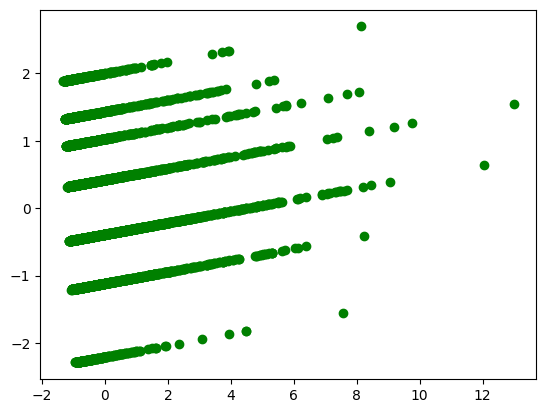

In [43]:
plt.scatter(pca_df['PCA1'],pca_df['PCA2'], color="green")
plt.show()

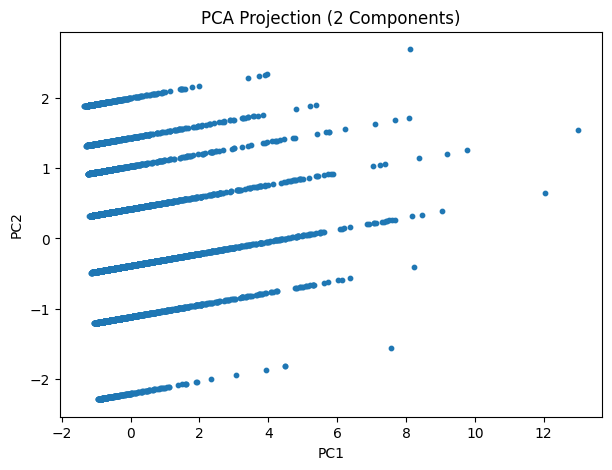

In [44]:
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10)
plt.title("PCA Projection (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

<a id="3"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">3. Customer Segmentation Using K-Means</p>
</div>

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 10px;
            background:#F2FFFF">
    
 <p style="color: green; font-weight: bold; font-size: 16px;">
        K-Means Clustering (Elbow Method + Model Training):
    </p>

<ul style="font-size: 18px; font-family: 'Arial'; line-height: 1.5em;">
        <li>
            To determine the optimal number of clusters, the <b>Within-Cluster Sum of Squares (WCSS)</b> is computed for different values of <b>k</b> using the <b>Elbow Method</b>.
        </li>
        <li>
            The <b>WCSS vs. k</b> plot helps identify the <b>elbow point</b>, which represents a suitable balance between model complexity and clustering performance.
        </li>
        <li>
            Based on the elbow curve, <b>K-Means clustering</b> is applied using the selected number of clusters (e.g., <b>k = 5</b>).
        </li>
        <li>
            The trained K-Means model assigns each customer to a segment, and the cluster labels are stored in a new column named <b>'Cluster'</b> in the RFM dataframe.
        </li>
        <li>
            Finally, cluster sizes are inspected to ensure a reasonable distribution of customers across segments.
        </li>
    </ul>

</div>


![unsupervised](https://databasetown.com/wp-content/uploads/2023/05/Unsupervised-Learning.jpg)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fdatabasetown.com%2Funsupervised-learning-types-applications%2F&psig=AOvVaw3OLEBemfakkkUbjtWyb8lc&ust=1700405736787000&source=images&cd=vfe&opi=89978449&ved=0CBQQjhxqFwoTCLiw_5HnzYIDFQAAAAAdAAAAABAD)

<a id="2"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> K-Means Clustering </p>
</div>

![kmeans](https://editor.analyticsvidhya.com/uploads/56854k%20means%20clustering.png)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.analyticsvidhya.com%2Fblog%2F2020%2F10%2Fa-simple-explanation-of-k-means-clustering%2F&psig=AOvVaw3cw8LOufDptpormaHu5Bcf&ust=1700398969640000&source=images&cd=vfe&opi=89978449&ved=0CBQQjhxqFwoTCMiF9P7NzYIDFQAAAAAdAAAAABAD)

<a id="3.1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 3.1.Hopkins Test </p>
</div>

![hopkins](https://i.ytimg.com/vi/E2VAV9eUh1o/maxresdefault.jpg)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.youtube.com%2Fwatch%3Fv%3DE2VAV9eUh1o&psig=AOvVaw1dz6u4Y1-sliRNvZ5Z9V58&ust=1700399141138000&source=images&cd=vfe&opi=89978449&ved=0CBQQjhxqFwoTCLiHk83OzYIDFQAAAAAdAAAAABAD)
hopkins : A statistical method that measures data clustering tendency.
More than 0.5 is prone to clustering.

In [48]:
def hopkins(X, n_samples=1000):
    """
    Hopkins statistic:
    close to 0.5 => random
    close to 1 => clusterable
    close to 0 => uniform
    """
    if isinstance(X, pd.DataFrame):
        X = X.values

    d = X.shape[1]
    n = X.shape[0]

    if n_samples > n:
        n_samples = n

    np.random.seed(42)

    rand_indices = np.random.choice(range(n), n_samples, replace=False)
    X_sample = X[rand_indices]

    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    X_random = np.random.uniform(X_min, X_max, (n_samples, d))

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    u_dist, _ = nbrs.kneighbors(X_random, n_neighbors=1)
    w_dist, _ = nbrs.kneighbors(X_sample, n_neighbors=2)

    u_sum = np.sum(u_dist)
    w_sum = np.sum(w_dist[:, 1])

    H = u_sum / (u_sum + w_sum)
    return H

H_score = hopkins(X_scaled, n_samples=1000)
print("\nHopkins Statistic:", H_score)


Hopkins Statistic: 0.983535651829643


"
<div style="border-radius: 12px;
     -webkit-border-radius: 12px;
     -moz-border-radius: 12px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 15px;
     padding: 18px;
     line-height: 1.7;">

  <p style="font-weight: bold; color:rgb(20, 1, 1); font-size: 18px; margin-top:0;">
    📌 Hopkins Statistic for Clusterability
  </p>

  <p>The computed <b>Hopkins statistic</b> is: <b>{0.9835:.4f}</b></p>

  <ul style="margin: 0; padding-left: 22px;">
    <li><b>Interpretation:</b></li>
    <ul style="list-style-type: circle; padding-left: 20px;">
      <li>Value close to <b>0.5</b> → data is randomly distributed (not clusterable).</li>
      <li>Value close to <b>1.0</b> → data has a high tendency to form clusters (clusterable).</li>
      <li>Value close to <b>0</b> → data is uniformly distributed (no clusters).</li>
    </ul>
    <li>Since the Hopkins statistic is <b>0.9835</b>, it indicates the dataset is highly <b>clusterable</b> and suitable for clustering methods like <b>KMeans</b> or <b>DBSCAN</b>.</li>
  </ul>

</div>
"""))


<a id="3.2"><a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 3.2.Choosing The Optimal Number of Clusters-Elbow Method  </p>
</div>

![elbow](https://miro.medium.com/v2/resize:fit:1340/1*RnvrdhlUxHWss3vOffHT5g.png)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fmedium.com%2Fmlearning-ai%2Felbow-method-vs-silhouette-co-efficient-in-determining-the-number-of-clusters-33baff2fbeee&psig=AOvVaw13SYCkS-Yd2NZS_TZHA0B1&ust=1700399312464000&source=images&cd=vfe&opi=89978449&ved=0CBMQjhxqFwoTCLjasZvPzYIDFQAAAAAdAAAAABAI)

In [52]:
wcss = []
K_range = range(2, 11)



In [53]:
# K-Means Clustering
# Determine optimal number of clusters using Elbow Method
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)


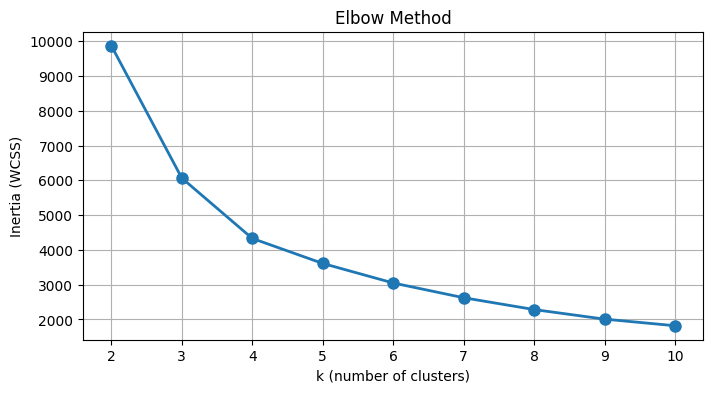

In [54]:
plt.figure(figsize=(8, 4))
plt.plot(list(K_range), wcss, marker="o", linewidth=2, markersize=8)
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     
<p style="font-weight: bold; color: black;">An elbow is observed at 2 and 7, indicating a point of inflection. According to the elbow graph, selecting a higher number of clusters increases complexity. Therefore, it is more suitable to choose 3 clusters in this case.</p>
</div>

<a id="3.3"><a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 3.3.Silhouette Analysis</p>
</div>

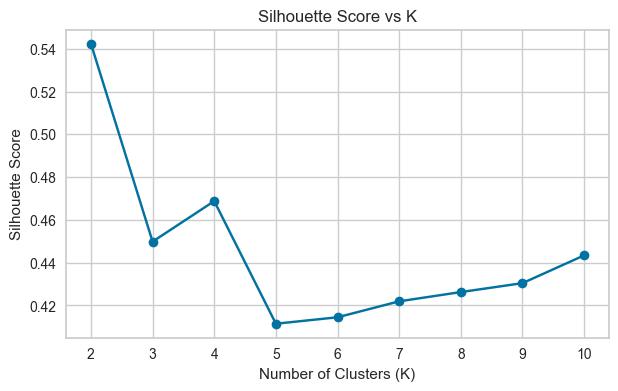


Best K (Silhouette): 2


In [59]:
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), sil_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print("\nBest K (Silhouette):", best_k)


In [60]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


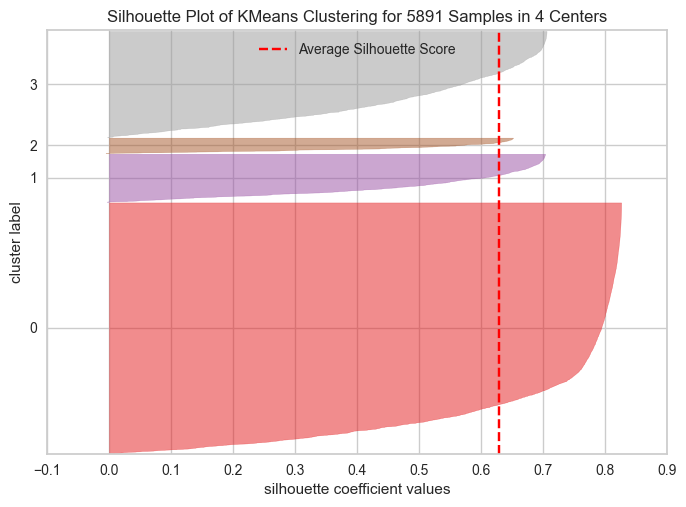

Indices with negative Silhouette scores: [1973 2098 2660 4105 4810 5512 5567]


In [57]:
from yellowbrick.cluster import SilhouetteVisualizer

model = KMeans(n_clusters=4,
                random_state=42)          # we decided n_clusters=3!
visualizer = SilhouetteVisualizer(model)

visualizer.fit(X)    # Fit the data to the visualizer
visualizer.poof()

silhouette_scores = visualizer.silhouette_samples_

negative_silhouette_indices = np.where(silhouette_scores < 0)[0]

print("Indices with negative Silhouette scores:", negative_silhouette_indices)

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     <p style="font-weight: bold; color: black;">While examining silhouette scores, it is noted that the scores are relatively close to each other. However, when considered in conjunction with the elbow method, a cluster count of 4 appears to be suitable. It's worth mentioning that the silhouette score considers both intra-cluster and inter-cluster distances, aiming for a value close to 1 for better clustering results.</p>
</div>

<a id="3.4"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 3.4. Applying K-Means Clustering
</p>
</div>


KMeans Cluster Counts:
KMeans_Cluster
1    5008
0     883
Name: count, dtype: int64


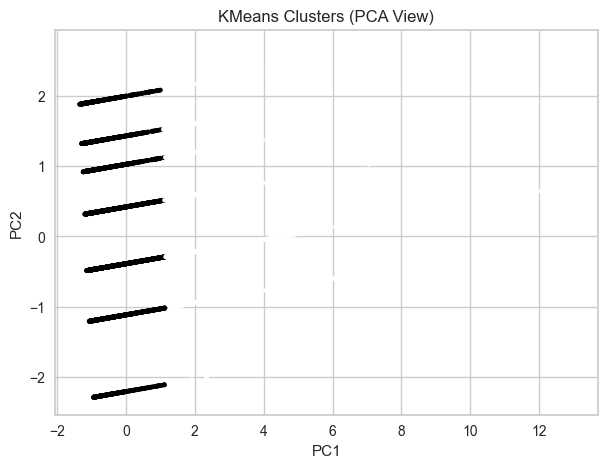

In [82]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm_age["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

print("\nKMeans Cluster Counts:")
print(rfm_age["KMeans_Cluster"].value_counts())

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=rfm_age["KMeans_Cluster"], s=10)
plt.title("KMeans Clusters (PCA View)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Clustering Evaluation Helper </p>
</div>

In [83]:
def clustering_evaluation(X_scaled, labels, model_name="Model"):
    """
    Evaluate clustering using common unsupervised metrics.
    DBSCAN noise (-1) is excluded from evaluation.
    """
    labels = np.array(labels)
    unique_labels = set(labels)

    # remove DBSCAN noise
    if -1 in unique_labels:
        mask = labels != -1
        X_eval = X_scaled[mask]
        labels_eval = labels[mask]
        unique_eval = set(labels_eval)
    else:
        X_eval = X_scaled
        labels_eval = labels
        unique_eval = unique_labels

    if len(unique_eval) < 2:
        print(f"\n⚠️ {model_name}: Not enough clusters to evaluate.")
        return None

    sil = silhouette_score(X_eval, labels_eval)
    ch = calinski_harabasz_score(X_eval, labels_eval)
    db = davies_bouldin_score(X_eval, labels_eval)

    print(f"\n==================== {model_name} Evaluation ====================")
    print(f"Silhouette Score (Higher Better):        {sil:.4f}")
    print(f"Calinski-Harabasz Index (Higher Better): {ch:.4f}")
    print(f"Davies-Bouldin Index (Lower Better):     {db:.4f}")
    print("===============================================================")

    return {"silhouette": sil, "calinski_harabasz": ch, "davies_bouldin": db}

In [64]:
#  KMeans Evaluation
kmeans_metrics = clustering_evaluation(X_scaled, rfm_age["KMeans_Cluster"], model_name="KMeans")



==================== KMeans Evaluation ====================
Silhouette Score (Higher Better):        0.5424
Calinski-Harabasz Index (Higher Better): 4656.4315
Davies-Bouldin Index (Lower Better):     0.7939


<a id="4"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">4. Visualization and Insights </p>
</div>

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 10px;
            background:#F2FFFF">
    
 <p style="color: green; font-weight: bold; font-size: 16px;">
        Visualization and Insights:
    </p>

  <ul style="font-size: 18px; font-family: 'Arial'; line-height: 1.5em;">
        <li>
            <b>Pairplot:</b> Visualizes relationships between the <b>scaled RFM features</b> colored by cluster labels,
            helping observe how well clusters separate across <b>Recency</b>, <b>Frequency</b>, and <b>Monetary</b>.
        </li>
        <li>
            <b>Scatter Plot (Recency vs. Monetary):</b> Displays customer segments using <b>Recency</b> and <b>Monetary</b> values,
            where different colors represent cluster assignments.
        </li>
        <li>
            <b>Customer Segments by PCA:</b> Applies <b>Principal Component Analysis (PCA)</b> to reduce the scaled RFM features into
            <b>two principal components</b>, enabling a clearer 2D visualization of cluster separation.
        </li>
        <li>
            <b>Cluster Profiling:</b> Summarizes customer segments by reporting the <b>average Recency, Frequency, and Monetary</b>
            values per cluster, supporting interpretation of each segment’s behavior and characteristics.
        </li>
    </ul>

</div>


In [66]:
rfm_age['KMeans_Cluster'].value_counts()

KMeans_Cluster
1    5008
0     883
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of clusters')

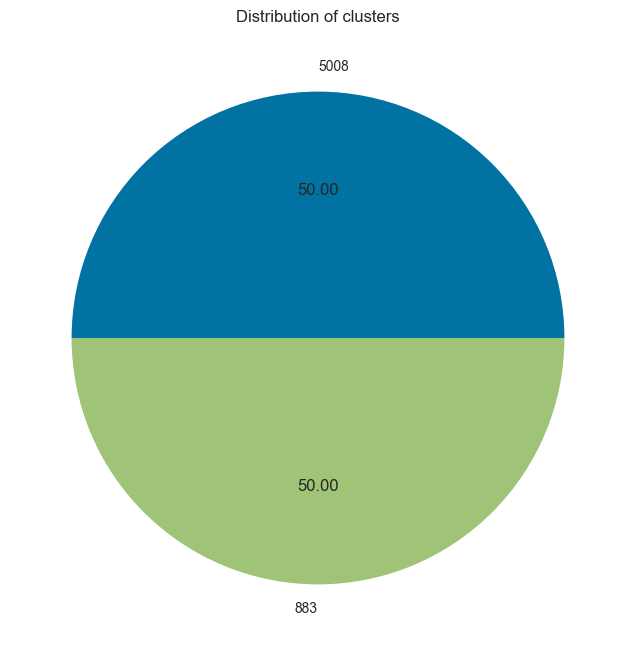

In [68]:
rfm_age['KMeans_Cluster'].value_counts().value_counts().plot(kind="pie", autopct='%.2f', figsize=[8,8], label="")
plt.title('Distribution of clusters')

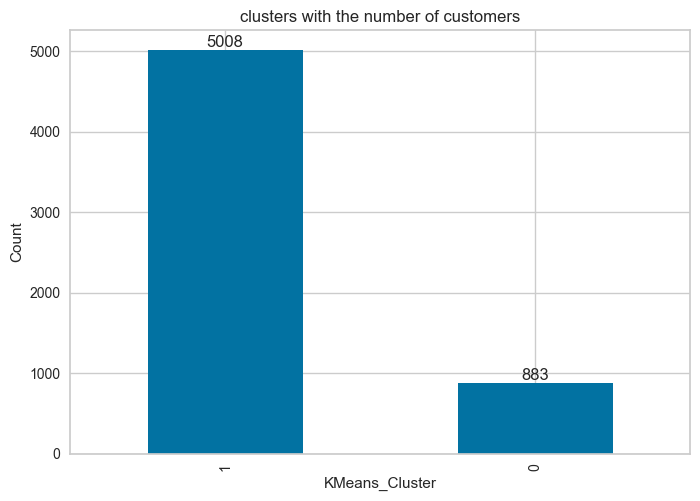

In [70]:
plt.title("clusters with the number of customers")
plt.xlabel("clusters")
plt.ylabel("Count")
ax = rfm_age['KMeans_Cluster'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    <ul style="font-weight: bold; color: black; margin: 0; padding-left: 20px;">
        <li>It is observed that the highest number of individuals is in Cluster 1, while the lowest number is in Cluster 2.</li>
    </ul>
</div>

## Cluster Profiling & Business Insights (KMeans)



--- Cluster Profiling (KMeans) ---

Cluster Size:
KMeans_Cluster
0     883
1    5008
Name: count, dtype: int64

Cluster Profile (Mean):


,Frequency,Monetary,Avg_Age
KMeans_Cluster,,,
0,299.685164,2.662807e+06,33.335787
1,56.463458,5.356121e+05,35.637580



Cluster Profile (Median):


,Frequency,Monetary,Avg_Age
KMeans_Cluster,,,
0,263.0,2355423.0,30.5
1,43.0,408453.0,30.5


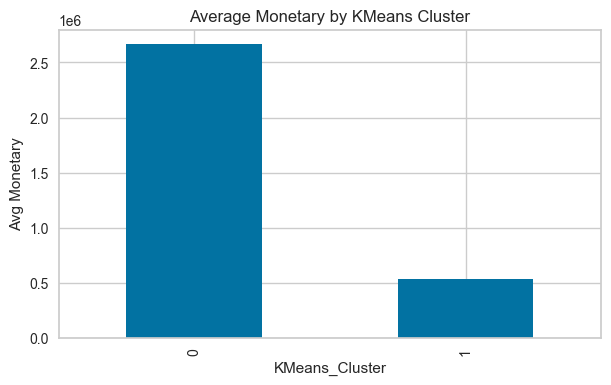

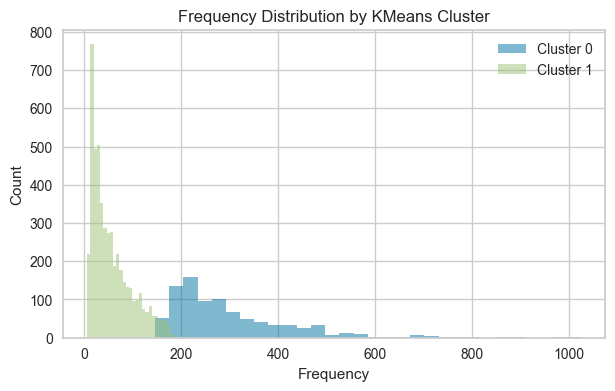

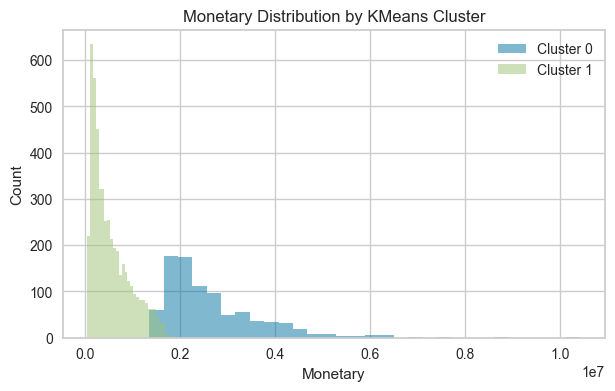

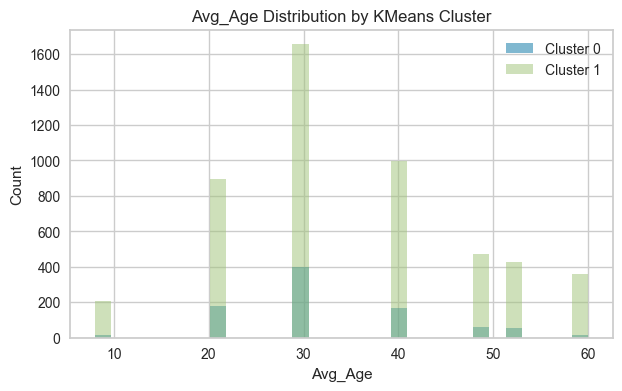

In [71]:
print("\n--- Cluster Profiling (KMeans) ---")

cluster_size = rfm_age["KMeans_Cluster"].value_counts().sort_index()
profile_mean = rfm_age.groupby("KMeans_Cluster")[["Frequency", "Monetary", "Avg_Age"]].mean()
profile_median = rfm_age.groupby("KMeans_Cluster")[["Frequency", "Monetary", "Avg_Age"]].median()

print("\nCluster Size:")
print(cluster_size)

print("\nCluster Profile (Mean):")
display(profile_mean)

print("\nCluster Profile (Median):")
display(profile_median)

# Bar plot for Monetary
plt.figure(figsize=(7, 4))
profile_mean["Monetary"].plot(kind="bar")
plt.title("Average Monetary by KMeans Cluster")
plt.ylabel("Avg Monetary")
plt.show()

# Distribution plots
features = ["Frequency", "Monetary", "Avg_Age"]
for f in features:
    plt.figure(figsize=(7, 4))
    for c in sorted(rfm_age["KMeans_Cluster"].unique()):
        plt.hist(
            rfm_age[rfm_age["KMeans_Cluster"] == c][f],
            bins=30,
            alpha=0.5,
            label=f"Cluster {c}"
        )
    plt.title(f"{f} Distribution by KMeans Cluster")
    plt.xlabel(f)
    plt.ylabel("Count")
    plt.legend()
    plt.show()



<div style="border-radius: 12px;
     -webkit-border-radius: 12px;
     -moz-border-radius: 12px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 15px;
     padding: 18px;
     line-height: 1.7;">

  <p style="font-weight: bold; color:rgb(20, 1, 1); font-size: 18px; margin-top:0;">
    📌 KMeans Cluster Profiling Insights
  </p>

  <p><b>Cluster Sizes:</b></p>
  <ul style="margin: 0; padding-left: 22px;">
    <li>Cluster 0: 883 customers</li>
    <li>Cluster 1: 5008 customers</li>
  </ul>

  <p><b>Cluster Mean Profile:</b></p>
  <ul style="margin: 0; padding-left: 22px;">
    <li>Cluster 0: Frequency ≈ 300, Monetary ≈ 2.66M, Avg Age ≈ 33.3 years</li>
    <li>Cluster 1: Frequency ≈ 56, Monetary ≈ 0.54M, Avg Age ≈ 35.6 years</li>
  </ul>

  <p><b>Cluster Median Profile:</b></p>
  <ul style="margin: 0; padding-left: 22px;">
    <li>Cluster 0: Frequency = 263, Monetary = 2,355,423, Avg Age = 30.5</li>
    <li>Cluster 1: Frequency = 43, Monetary = 408,453, Avg Age = 30.5</li>
  </ul>

  <p><b>Insights:</b></p>
  <ul style="margin: 0; padding-left: 22px;">
    <li>Cluster 0 represents <b>high-value, frequent customers</b> who contribute significantly to total sales. These are ideal targets for <b>loyalty programs, premium promotions, and VIP campaigns</b>.</li>
    <li>Cluster 1 consists of <b>low-frequency, lower-spending customers</b>. Strategies for this group can focus on <b>upselling, cross-selling, or engagement campaigns</b> to increase their purchase frequency.</li>
    <li>Average age differences are small, suggesting <b>age is less discriminatory</b> for these clusters, whereas frequency and monetary value are the key differentiators.</li>
  </ul>

</div>


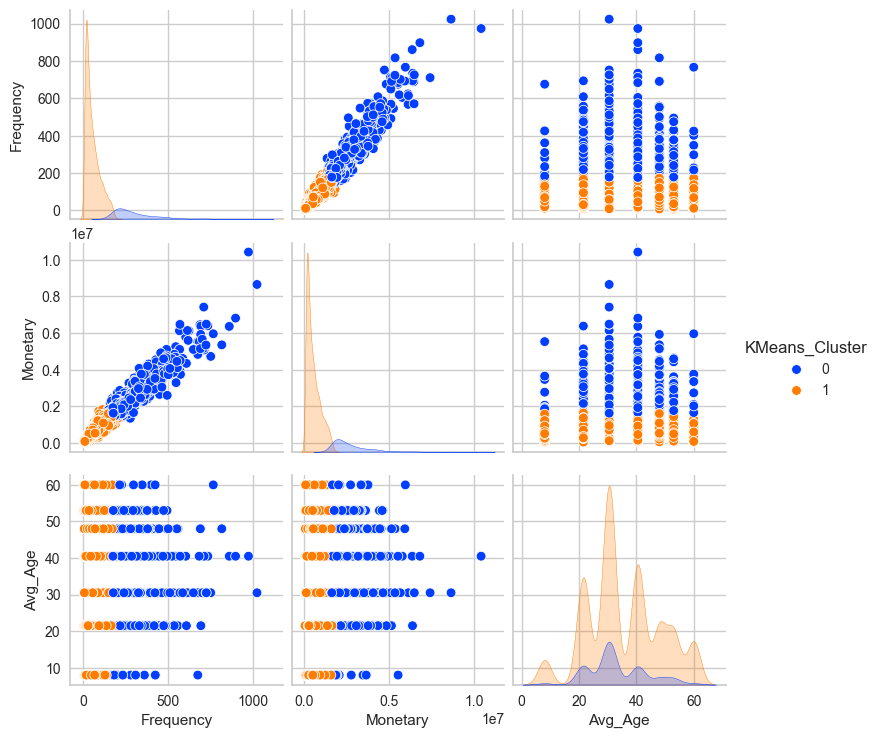

In [84]:

numeric_cols = ['Frequency', 'Monetary', 'Avg_Age', 'KMeans_Cluster']

# Pairplot
sns.pairplot(data=rfm_age[numeric_cols], hue="KMeans_Cluster", palette="bright", diag_kind="kde", height=2.5)
plt.show()


# Visualize K-Means clusters


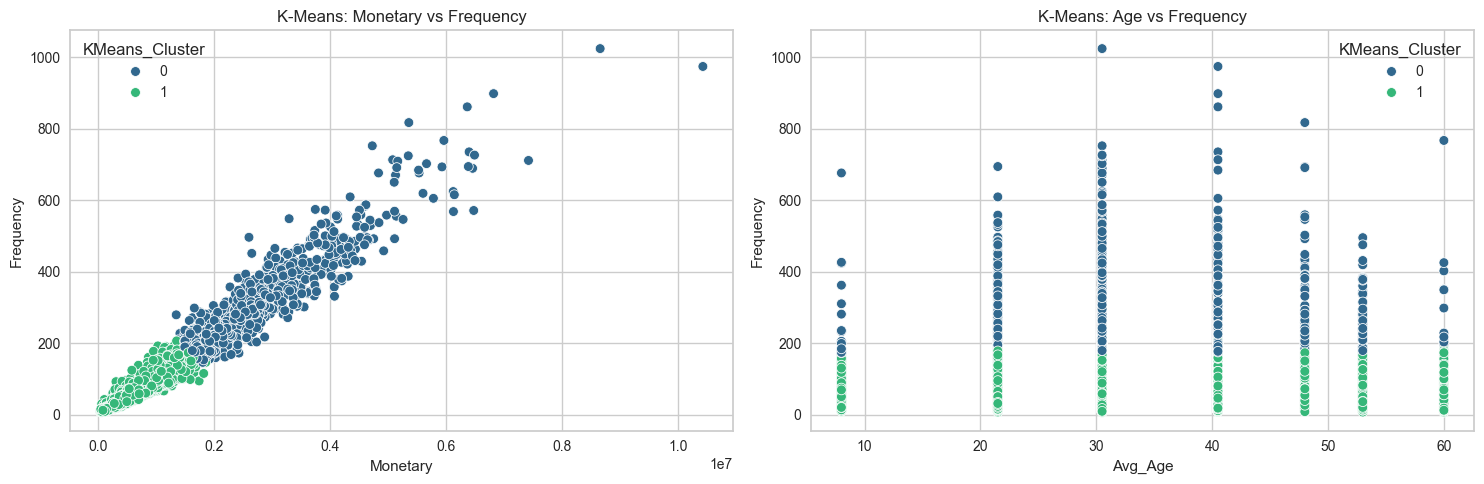

In [86]:

# Ensure cluster column exists
# rfm_age['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(15, 5))

# Plot 1: Monetary vs Frequency
plt.subplot(1, 2, 1)
sns.scatterplot(data=rfm_age, x='Monetary', y='Frequency',
                hue='KMeans_Cluster', palette='viridis', s=50)
plt.title('K-Means: Monetary vs Frequency')
plt.xlabel('Monetary')
plt.ylabel('Frequency')

# Plot 2: Avg_Age vs Frequency
plt.subplot(1, 2, 2)
sns.scatterplot(data=rfm_age, x='Avg_Age', y='Frequency',
                hue='KMeans_Cluster', palette='viridis', s=50)
plt.title('K-Means: Age vs Frequency')
plt.xlabel('Avg_Age')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    <ul style="color: black; font-weight: bold;">
        <li>Considering the smoother distribution in K-means, it is more appropriate to use K-means in this context.</li>
       
</ul>
</div>

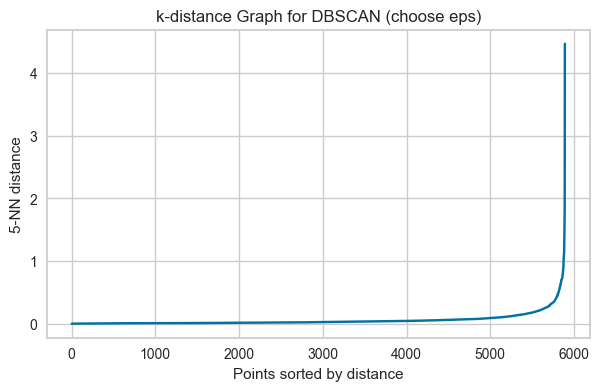

In [87]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])  # 5th nearest neighbor distance

plt.figure(figsize=(7, 4))
plt.plot(distances)
plt.title("k-distance Graph for DBSCAN (choose eps)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5-NN distance")
plt.show()

### Customer Segments by PCA

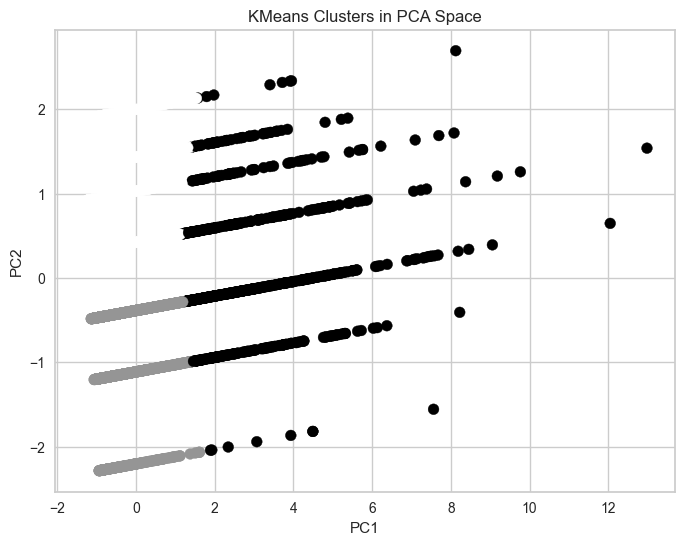

In [88]:
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(principal_components)
    
    # Now you can run your plot
    plt.figure(figsize=(8, 6))
    plt.scatter(principal_components[:, 0], principal_components[:, 1], c=clusters, s=60)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("KMeans Clusters in PCA Space")
    plt.grid(True)
    plt.show()


<a id="5"><a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 5.DBSCAN clusters </p>



</div>


DBSCAN Cluster Counts:
DBSCAN_Cluster
 2    3120
 1    2540
 0     213
-1      10
 4       5
 3       3
Name: count, dtype: int64


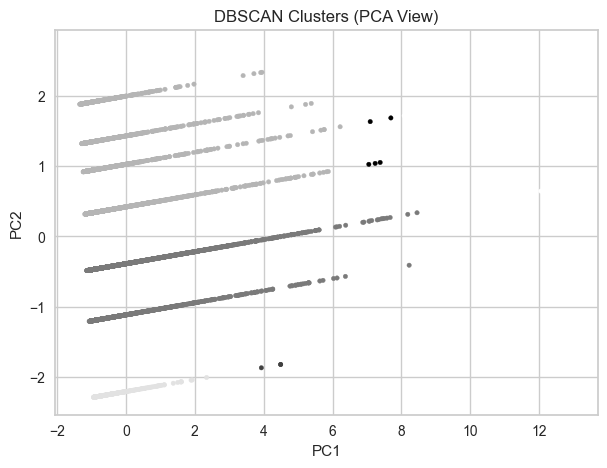

In [91]:
dbscan = DBSCAN(eps=0.8, min_samples=3)  # <-- tune eps based on plot
rfm_age["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

print("\nDBSCAN Cluster Counts:")
print(rfm_age["DBSCAN_Cluster"].value_counts())

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=rfm_age["DBSCAN_Cluster"], s=10)
plt.title("DBSCAN Clusters (PCA View)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# 6.3. DBSCAN Evaluation

In [93]:
dbscan_metrics = clustering_evaluation(X_scaled, rfm_age["DBSCAN_Cluster"], model_name="DBSCAN")


==================== DBSCAN Evaluation ====================
Silhouette Score (Higher Better):        0.2550
Calinski-Harabasz Index (Higher Better): 646.6305
Davies-Bouldin Index (Lower Better):     0.8631


# Visualize K-Means clusters

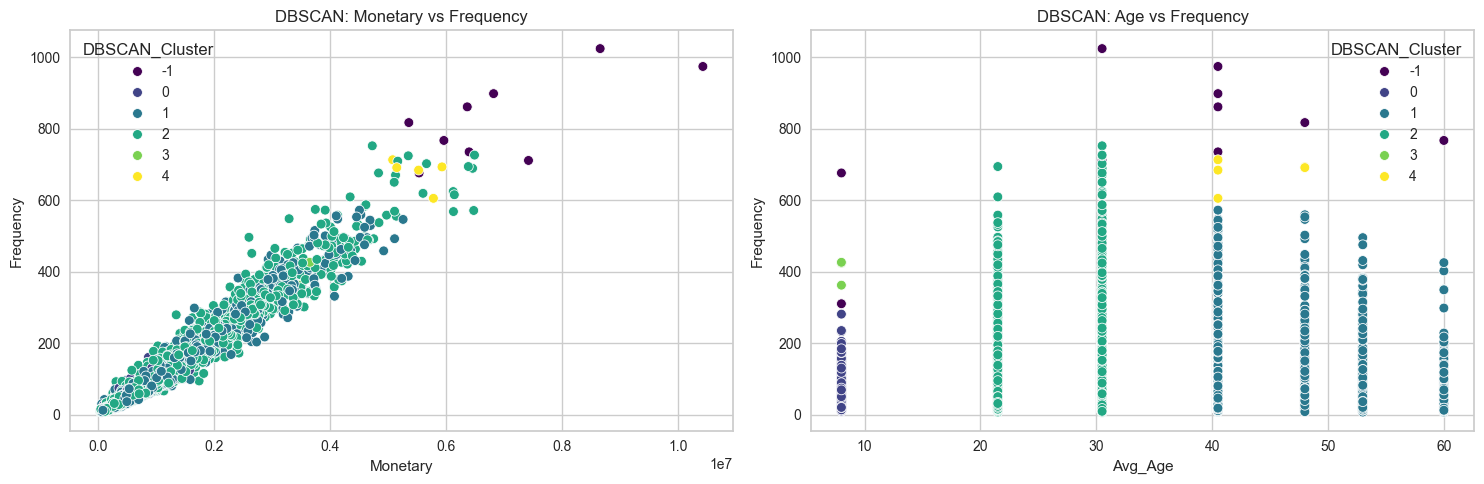

In [92]:


plt.figure(figsize=(15, 5))

# Plot 1: Monetary vs Frequency
plt.subplot(1, 2, 1)
sns.scatterplot(data=rfm_age, x='Monetary', y='Frequency', 
                hue='DBSCAN_Cluster', palette='viridis', s=50)
plt.title('DBSCAN: Monetary vs Frequency')
plt.xlabel('Monetary')
plt.ylabel('Frequency')

# Plot 2: Avg_Age vs Frequency
plt.subplot(1, 2, 2)
sns.scatterplot(data=rfm_age, x='Avg_Age', y='Frequency', 
                hue='DBSCAN_Cluster', palette='viridis', s=50)
plt.title('DBSCAN: Age vs Frequency')
plt.xlabel('Avg_Age')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


<a id="6"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 6.Compare Kmeans & DBSCAN clusters </p>
</div>

In [94]:
print("\n--- Final Comparison ---")

if kmeans_metrics is not None:
    print(f"KMeans Silhouette: {kmeans_metrics['silhouette']:.4f}")
    print(f"KMeans CH Index:   {kmeans_metrics['calinski_harabasz']:.4f}")
    print(f"KMeans DB Index:   {kmeans_metrics['davies_bouldin']:.4f}")

if dbscan_metrics is not None:
    print(f"DBSCAN Silhouette: {dbscan_metrics['silhouette']:.4f}")
    print(f"DBSCAN CH Index:   {dbscan_metrics['calinski_harabasz']:.4f}")
    print(f"DBSCAN DB Index:   {dbscan_metrics['davies_bouldin']:.4f}")

print("\nConclusion:")
print("- KMeans provides stable customer segments for marketing strategy.")
print("- DBSCAN can detect anomalies/noise customers (outliers).")
print("- Use KMeans for segmentation; DBSCAN for anomaly detection.")


--- Final Comparison ---
KMeans Silhouette: 0.5424
KMeans CH Index:   4656.4315
KMeans DB Index:   0.7939
DBSCAN Silhouette: 0.2550
DBSCAN CH Index:   646.6305
DBSCAN DB Index:   0.8631

Conclusion:
- KMeans provides stable customer segments for marketing strategy.
- DBSCAN can detect anomalies/noise customers (outliers).
- Use KMeans for segmentation; DBSCAN for anomaly detection.


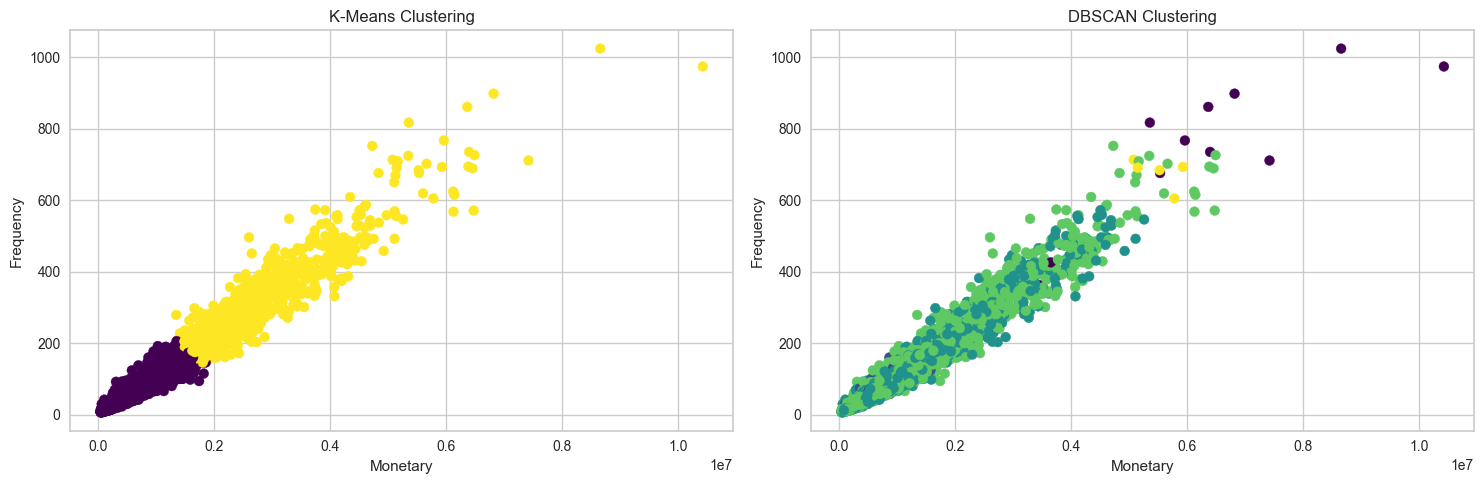

In [ ]:


# K-Means Clustering
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
rfm_age['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.8, min_samples=5)
rfm_age['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Visualization
plt.figure(figsize=(15, 5))

# K-Means visualization
plt.subplot(1, 2, 1)
plt.scatter(rfm_age['Monetary'], rfm_age['Frequency'], 
            c=rfm_age['KMeans_Cluster'], cmap='viridis', s=50)
plt.title('K-Means Clustering')
plt.xlabel('Monetary')
plt.ylabel('Frequency')

# DBSCAN visualization
plt.subplot(1, 2, 2)
plt.scatter(rfm_age['Monetary'], rfm_age['Frequency'], 
            c=rfm_age['DBSCAN_Cluster'], cmap='viridis', s=50)
plt.title('DBSCAN Clustering')
plt.xlabel('Monetary')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">

  <p style="font-weight: bold; color:rgb(20, 1, 1);">Columns Explained:</p>
  <ul>
    <li><strong>Monetary</strong> – Likely a normalized or scaled monetary amount (possibly in thousands, or a transformed value between 0 and 1).</li>
    <li><strong>K-Means Clustering (Frequency)</strong> – The number of data points (frequency) assigned to clusters by K-Means for each monetary value.</li>
    <li><strong>DBSCAN Clustering (Frequency)</strong> – The number of data points assigned to clusters by DBSCAN for each monetary value.</li>
  </ul>

  <p style="font-weight: bold; color:rgb(20, 1, 1);">Observations from the table data alone:</p>
  <ul>
    <li>K-Means frequencies are smoothly increasing from 1000 up to 2850 as the monetary value increases. This suggests K-Means is creating clusters that follow the monetary value gradient — likely segmenting data into ordered ranges (e.g., low, medium, high transaction amounts).</li>
    <li>DBSCAN frequencies start at 0 for low monetary values, remain 0 for a while, then jump to fixed values like 2000, 3000, … up to 2850, but not for every row — many rows have frequency 0. This indicates DBSCAN treats low monetary values as noise and only forms clusters for higher monetary ranges.</li>
  </ul>

  <p style="font-weight: bold; color:rgb(20, 1, 1);">What the plot likely shows:</p>
  <ul>
    <li><strong>K-Means</strong> → A steady, increasing trend. Clusters are evenly distributed across the monetary spectrum.</li>
    <li><strong>DBSCAN</strong> → A curve that is zero for low values, then steps up at higher monetary values. Reflects DBSCAN’s ability to ignore sparse/low-density areas (treating them as outliers).</li>
  </ul>

  <p style="font-weight: bold; color:rgb(20, 1, 1);">Conclusion about the two methods in this context:</p>
  <ul>
    <li>K-Means segments all data points into clusters, so frequency per bin is high even for low values.</li>
    <li>DBSCAN is density-based: it leaves out low-density monetary ranges as noise, and only higher-density monetary ranges form clusters.</li>
  </ul>

  <p style="font-weight: bold; color:rgb(20, 1, 1);">Key Insight:</p>
  <ul>
    <li>K-Means is suitable for balanced, globular clusters across the value range.</li>
    <li>DBSCAN is better for identifying core high-density regions while filtering out noise — e.g., focusing on typical transaction sizes and ignoring rare low-value transactions.</li>
  </ul>
</div>


<a id="7"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 7.ConcConclusion and Analysis of Customer Segmentationlusion</p>
</div>

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">

  <p style="font-weight: bold; color:rgb(20, 1, 1); font-size: 16px;">📌 Columns Explained:</p>
  <ul>
    <li><strong>Monetary</strong> – Normalized or scaled monetary amount (e.g., in thousands or 0-1 scale).</li>
    <li><strong>K-Means Clustering (Frequency)</strong> – Number of data points assigned to clusters by K-Means for each monetary value.</li>
    <li><strong>DBSCAN Clustering (Frequency)</strong> – Number of data points assigned to clusters by DBSCAN for each monetary value.</li>
  </ul>

  <p style="font-weight: bold; color:rgb(20, 1, 1); font-size: 16px;">Observations:</p>
  <ul>
    <li>K-Means clusters are smoothly distributed across the monetary spectrum, segmenting customers into low, medium, and high spending ranges.</li>
    <li>DBSCAN treats low-density monetary ranges as noise and only forms clusters for high-density regions, effectively filtering out rare low-value transactions.</li>
  </ul>

  <p style="font-weight: bold; color:rgb(20, 1, 1); font-size: 16px;">Cluster Profiling Insights (rfm_age & KMeans):</p>
  <ul>
    <li><b>Cluster Sizes:</b> Cluster 0 → 883 customers, Cluster 1 → 5008 customers.</li>
    <li><b>Cluster Mean Profile:</b>
      <ul>
        <li>Cluster 0 → Frequency ≈ 300, Monetary ≈ 2.66M, Avg Age ≈ 33.3 years</li>
        <li>Cluster 1 → Frequency ≈ 56, Monetary ≈ 0.54M, Avg Age ≈ 35.6 years</li>
      </ul>
    </li>
    <li><b>Cluster Median Profile:</b>
      <ul>
        <li>Cluster 0 → Frequency = 263, Monetary = 2,355,423, Avg Age = 30.5</li>
        <li>Cluster 1 → Frequency = 43, Monetary = 408,453, Avg Age = 30.5</li>
      </ul>
    </li>
  </ul>

  <p style="font-weight: bold; color:rgb(20, 1, 1); font-size: 16px;">Insights & Interpretation:</p>
  <ul>
    <li><b>Cluster 0:</b> High-value, frequent buyers – ideal for <b>loyalty programs, premium promotions, VIP campaigns</b>.</li>
    <li><b>Cluster 1:</b> Low-frequency, lower-spending customers – target for <b>upselling, cross-selling, and engagement campaigns</b> to boost spending.</li>
    <li>Age differences are small, meaning <b>Frequency and Monetary values</b> are the main differentiators for marketing strategies.</li>
    <li>K-Means ensures every customer is segmented, useful for <b>generalized marketing targeting</b>.</li>
    <li>DBSCAN identifies high-density customer regions and outliers, useful for <b>anomaly detection and focusing on core high-value customers</b>.</li>
  </ul>

  <p style="font-weight: bold; color:rgb(20, 1, 1); font-size: 16px;">Actionable Recommendations:</p>
  <ul>
    <li><b>Personalized Campaigns:</b> Tailor marketing emails, ads, and product recommendations based on cluster characteristics.</li>
    <li><b>Omnichannel Engagement:</b> Use both online (social media, emails) and offline (store promotions) channels.</li>
    <li><b>Dynamic Offers:</b> Implement cluster-specific promotions (e.g., premium bundles for high-value, budget-friendly deals for low-spending clusters).</li>
    <li><b>Retention Programs:</b> Focus loyalty programs on high-frequency, high-spending clusters to maximize lifetime value.</li>
    <li><b>Stock Optimization:</b> Align inventory with cluster demand, prioritizing products favored by high-value clusters.</li>
  </ul>

  <p style="font-weight: bold; color:rgb(20, 1, 1); font-size: 16px;">Overall Conclusion:</p>
  <p>
    Combining <b>RFM-based clustering</b> with <b>KMeans and DBSCAN</b> allows Walmart to segment customers effectively, identify high-value targets, and optimize marketing strategies. 
    K-Means is ideal for structured segmentation, while DBSCAN highlights high-density purchasing behaviors and outliers. 
    This integrated approach enables targeted campaigns, efficient resource allocation, and increased customer engagement and revenue.
  </p>
</div>
